### Train and validate semantic segmentation models to delineate FMV. 
This notebook trains a **binary semantic-segmentation model** to delineate field margin nvegetation (FMV) from background using WorldView-3 image chips.

The attached workflow used a U-Net with a ResNet-34 encoder and the band combination-Red edge + Yellow + Coastal blue. 


#### Author's detail:

Satya Prakash, Michael Wachendorf, Sunil Nautiyal, Jayan Wijesingha

Section of Grassland Science and Renewable Plant Resources, Faculty of Organic Agricultural Sciences,

University of Kassel, Steinstraße 19, D-37213 Witzenhausen Germany

For any query: satyaprakash724.sp@gmail.com; satya.prakash@uni-kassel.de

In [1]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow import keras
import segmentation_models as sm
import albumentations as A
import keras.backend as K

2026-08-12 15:17:54.755440: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-12 15:17:55.409209: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/cuda-11.2/lib64:/usr/local/cuda-11.2/extras/CUPTI/lib64
2026-08-12 15:17:55.409285: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/cuda-11.2/lib64:/usr/local/cuda-11.2/extras/CUPTI/

Segmentation Models: using `keras` framework.


/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# Set common parameters
n_classes = 1
activation = 'sigmoid'
LR = 5e-4
batch_size = 8
epochs = 50
optim = keras.optimizers.Adam(LR)

2026-08-12 15:17:56.919607: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-12 15:17:56.919873: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-12 15:17:56.928053: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-12 15:17:56.928394: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-12 15:17:56.928576: I tensorflow/compiler/xla/stream_executo

In [3]:
# Function to load images and masks
def load_images_and_masks(image_dir, mask_dir, bands=[6, 4, 1]):
    images = []
    masks = []
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))
    
    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)
        
        with rasterio.open(img_path) as src:
            img = np.stack([src.read(band) for band in bands], axis=-1)
        img = np.clip(img, 0, np.percentile(img, 99)).astype('float32')
        
        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)
        
        images.append(img)
        masks.append(mask)
    
    images = np.array(images)
    masks = np.array(masks)[..., np.newaxis]
    
    return images, masks

In [4]:
def weighted_dice_loss(weights):
    def loss(y_true, y_pred):
        # Ensure y_true and y_pred are float32 tensors
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Apply class weights
        # Multiply each class in y_true and y_pred by its corresponding weight
        weighted_y_true = y_true * weights
        weighted_y_pred = y_pred * weights
        
        # Flatten the tensors for Dice Loss calculation
        y_true_f = tf.keras.backend.flatten(weighted_y_true)
        y_pred_f = tf.keras.backend.flatten(weighted_y_pred)
        
        # Calculate intersection and union
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        sum_ = tf.reduce_sum(y_true_f + y_pred_f)
        
        # Compute Dice Loss
        dice_loss = 1 - (2. * intersection + 1e-7) / (sum_ + 1e-7)
        return dice_loss
    return loss

In [5]:
# Define custom loss and metrics
dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss()
total_loss = dice_loss + focal_loss

metrics = [
    sm.metrics.IOUScore(threshold=0.5),
    sm.metrics.FScore(threshold=0.5),
]

In [6]:
# Augmentation functions
def get_training_augmentation():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=10, shift_limit=0.1, p=0.5),
        #A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),  # Reduced limits
        #A.OneOf([
            #A.Blur(blur_limit=3, p=1),
            #A.MotionBlur(blur_limit=3, p=1),
            #A.MedianBlur(blur_limit=3, p=1),
        #], p=0.5),
        A.PadIfNeeded(min_height=128, min_width=128, always_apply=True, border_mode=0, value=0),
        #A.RandomCrop(height=128, width=128, always_apply=True)
    ])


In [7]:
def get_validation_augmentation():
    return A.Compose([
        A.PadIfNeeded(min_height=128, min_width=128, always_apply=True, border_mode=0, value=0)
    ])

In [8]:
def get_preprocessing(preprocessing_fn):
    return A.Compose([
        A.Lambda(image=preprocessing_fn),
    ])

In [9]:
def load_images_and_masks(image_dir, mask_dir, bands=[6, 4, 1], augmentations=None):
    images = []
    masks = []
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))
    
    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)
        
        # Load image and extract specified bands
        with rasterio.open(img_path) as src:
            img = np.stack([src.read(band) for band in bands], axis=-1)
        img = np.clip(img, 0, np.percentile(img, 99)).astype('float32')
        
        # Load mask and binarize
        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)
        
        # Apply augmentations if provided
        if augmentations:
            augmented = augmentations(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        
        images.append(img)
        masks.append(mask)
    
    images = np.array(images)
    masks = np.array(masks)[..., np.newaxis]  # Add channel dimension to masks
    
    return images, masks

In [10]:
# Paths for training, validation, and testing
base_dir = "/home/pc4dl/satya/Model_development/Sample2"
train_image_dir = os.path.join(base_dir, 'Training', 'Image')
train_mask_dir = os.path.join(base_dir, 'Training', 'labels')
val_image_dir = os.path.join(base_dir, 'Validation', 'Image')
val_mask_dir = os.path.join(base_dir, 'Validation', 'labels')
#test_image_dir = os.path.join(base_dir, 'TestingR', 'Image')
#test_mask_dir = os.path.join(base_dir, 'TestingR', 'labels')

In [11]:
# Load images and masks
print("Loading images and masks...")
images, masks = load_images_and_masks(train_image_dir, train_mask_dir)

Loading images and masks...


In [12]:
# Load training data with augmentation
print("Loading training data...")
X_train, y_train = load_images_and_masks(
    train_image_dir, 
    train_mask_dir, 
    augmentations=get_training_augmentation()
)

# Load validation data without heavy augmentation (only padding to match input size)
print("Loading validation data...")
X_val, y_val = load_images_and_masks(
    val_image_dir, 
    val_mask_dir, 
    augmentations=get_validation_augmentation()
)

Loading training data...
Loading validation data...


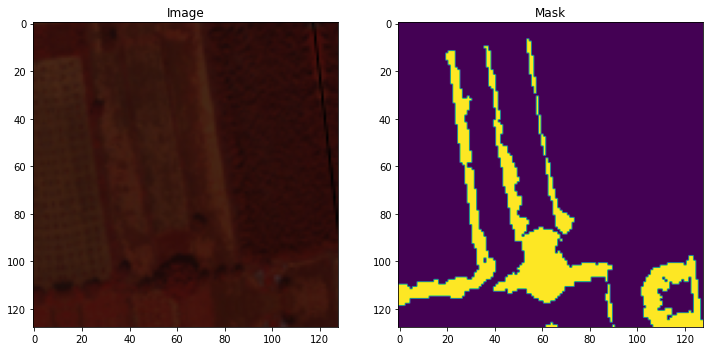

In [13]:
## Train set
tr_num = random.randint(0, np.shape(X_train)[0]-1)
plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(X_train[tr_num])
plt.title('Image')
plt.subplot(122)
plt.imshow(y_train[tr_num])
plt.title('Mask')
plt.show()

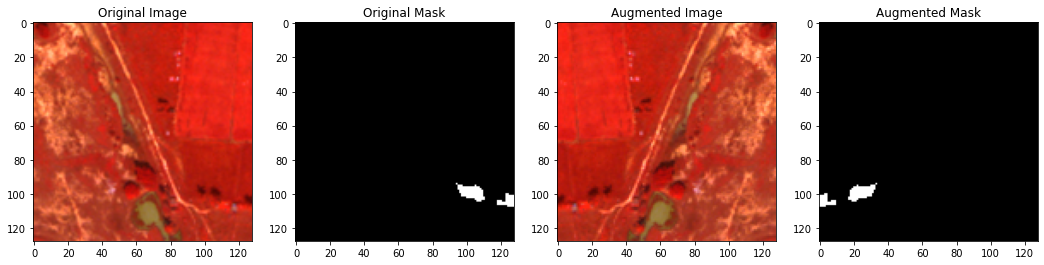

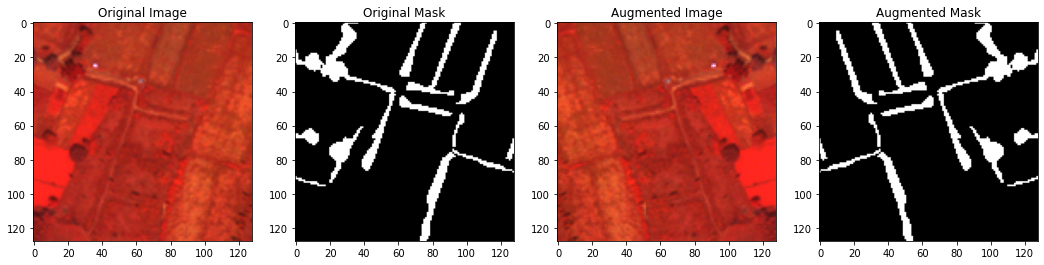

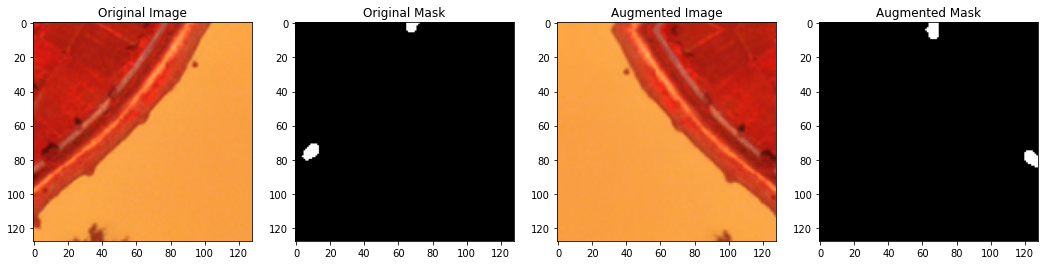

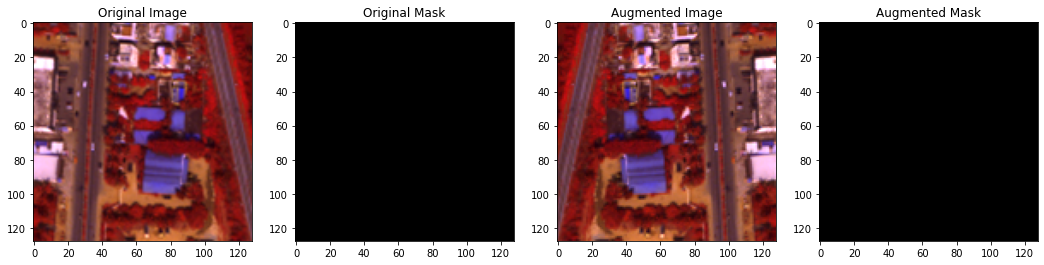

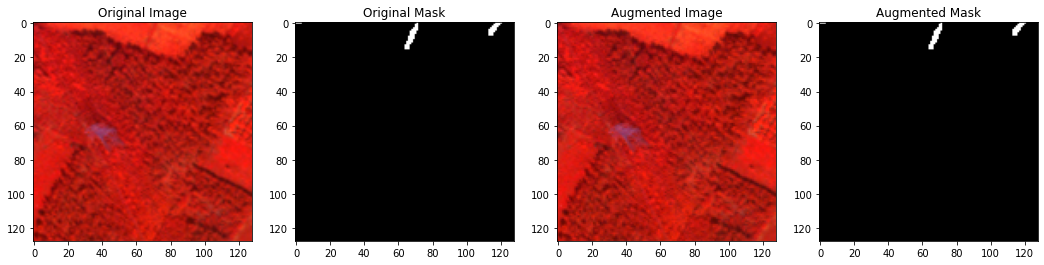

In [14]:
# Function to visualize augmented images and masks
def visualize_augmentation(image_dir, mask_dir, augmentations, num_samples=5, bands=[6, 4, 1]):
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))
    
    for i in range(num_samples):
        idx = random.randint(0, len(image_files) - 1)
        
        img_path = os.path.join(image_dir, image_files[idx])
        mask_path = os.path.join(mask_dir, mask_files[idx])
        
        with rasterio.open(img_path) as src:
            img = np.stack([src.read(band) for band in bands], axis=-1).astype(np.float32)

        img = np.clip(img, 0, np.percentile(img, 99))  # Clip out extreme values
        
        # Normalize to [0, 1] before augmentation
        img = (img - img.min()) / (img.max() - img.min())

        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)
        
        # Apply augmentation
        augmented = augmentations(image=img, mask=mask)
        aug_img = augmented['image']
        aug_mask = augmented['mask']

        # Convert images for visualization
        img_display = (img * 255).astype('uint8')  # Correctly scale for display
        aug_img_display = (aug_img * 255).astype('uint8')  # Scale augmented image correctly
        
        # Plot images
        plt.figure(figsize=(18, 6))
        plt.subplot(141)
        plt.imshow(img_display, interpolation='bilinear')
        plt.grid(False)
        plt.title('Original Image')

        plt.subplot(142)
        plt.imshow(mask, cmap='gray')
        plt.grid(False)
        plt.title('Original Mask')

        plt.subplot(143)
        plt.imshow(aug_img_display)
        plt.grid(False)
        plt.title('Augmented Image')

        plt.subplot(144)
        plt.imshow(aug_mask, cmap='gray')
        plt.grid(False)
        plt.title('Augmented Mask')

        plt.show()

# Call the function to visualize augmented data
augmentations_pipeline = get_training_augmentation()
visualize_augmentation(train_image_dir, train_mask_dir, augmentations_pipeline)

In [15]:
# Define backbone and preprocessing function
BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

In [16]:
# Preprocess images
X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)

In [17]:
# Define the model
model = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=n_classes, activation=activation)

# Compile the model
weights = tf.constant([0.052, 0.948])  # Weights for two classes (e.g., background, object)
#weights = tf.constant([0.1, 0.9])  # Weights for two classes (e.g., background, object)
# Create a custom loss that combines Dice and Focal Loss
weighted_dice = weighted_dice_loss(weights)
focal_loss = sm.losses.BinaryFocalLoss()

total_loss = lambda y_true, y_pred: weighted_dice(y_true, y_pred) + focal_loss(y_true, y_pred)

model.compile(optimizer=optim, loss=total_loss, metrics=metrics)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=10,           # Number of epochs with no improvement after which training will stop
    restore_best_weights=True  # Restore model weights from the epoch with the best validation loss
)

# Print model summary
print(model.summary())

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 data (InputLayer)              [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 bn_data (BatchNormalization)   (None, None, None,   9           ['data[0][0]']                   
                                3)                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, None, None,   0          ['bn_data[0][0]']                
                                3)                                                          

In [ ]:
# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)
# Save the best model
model.save("UNET_resnet34_641_2.h5")
print("Model saved!")

In [18]:
## Load the final or best model
import tensorflow as tf

# Load the model
model_path = "/home/pc4dl/satya/Model_development/UNET_resnet34_641.h5"
model = tf.keras.models.load_model(model_path, compile=False)
#model = tf.keras.models.load_model("UNET_resnet34_best.h5", compile=False)

# Define metrics
metrics = [
    'binary_accuracy',  
    sm.metrics.IOUScore(threshold=0.5),  
    sm.metrics.FScore(threshold=0.5)
]

# Recompile the model with the correct metrics
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4), 
              loss=total_loss, 
              metrics=metrics)

print("Model loaded and recompiled successfully!")

Model loaded and recompiled successfully!


## Rural Test experiment

In [87]:
# Load test data (Rural Zone)
test_image_dir = os.path.join(base_dir, 'TestingR', 'Image')
test_mask_dir = os.path.join(base_dir, 'TestingR', 'labels')

In [88]:
# Load test images and masks (without augmentation)
print("Loading test data...")
X_test, y_test = load_images_and_masks(test_image_dir, test_mask_dir)

Loading test data...


In [89]:
# Preprocess test images
preprocess_input = sm.get_preprocessing('resnet34')
X_test = preprocess_input(X_test)
# Predict on test data
y_pred = model.predict(X_test)

# Apply a threshold to convert probabilities to binary masks
y_pred_thresholded = (y_pred > 0.5).astype('float32')

5/5 [==============================] - 0s 27ms/step


In [90]:
from sklearn.metrics import precision_score, recall_score, average_precision_score
import numpy as np

# Evaluate model on test data (Loss, Binary Accuracy, IOU, F1 Score)
loss, binary_accuracy, iou_score, f1_score = model.evaluate(X_test, y_test, verbose=1)

# Make predictions on test data
y_test_pred = model.predict(X_test, batch_size=batch_size, verbose=1)

# Convert probabilities to binary masks (threshold = 0.5)
y_test_pred_binary = (y_test_pred > 0.7).astype(np.uint8)

# Flatten arrays for metric calculation
y_test_flat = y_test.flatten()
y_test_pred_flat = y_test_pred_binary.flatten()

# Calculate Precision, Recall, and PR-AUC
test_precision = precision_score(y_test_flat, y_test_pred_flat)
test_recall = recall_score(y_test_flat, y_test_pred_flat)
test_pr_auc = average_precision_score(y_test_flat, y_test_pred_flat)

# Print all test metrics
print("\n=== Test Evaluation Metrics ===")
print("Test Loss:", loss)
print("Test Binary Accuracy:", binary_accuracy)
print("Test IOU Score:", iou_score)
print("Test F1 Score:", f1_score)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test PR-AUC:", test_pr_auc)

18/18 [==============================] - 0s 11ms/step

=== Test Evaluation Metrics ===
Test Loss: 0.5832365155220032
Test Binary Accuracy: 0.939917266368866
Test IOU Score: 0.411185085773468
Test F1 Score: 0.5822979807853699
Test Precision: 0.5996088204675226
Test Recall: 0.5693241316511508
Test PR-AUC: 0.3718431489456039


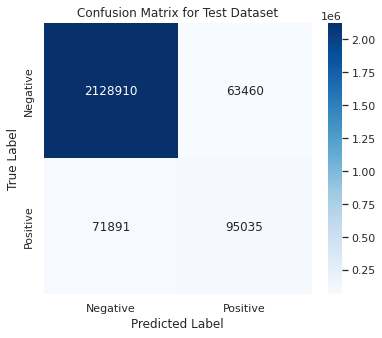

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test_flat, y_test_pred_flat)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Test Dataset")
plt.show()

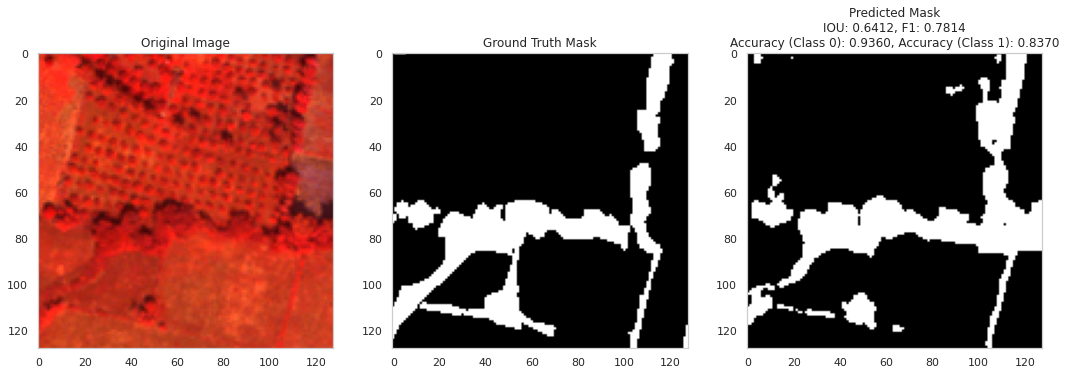

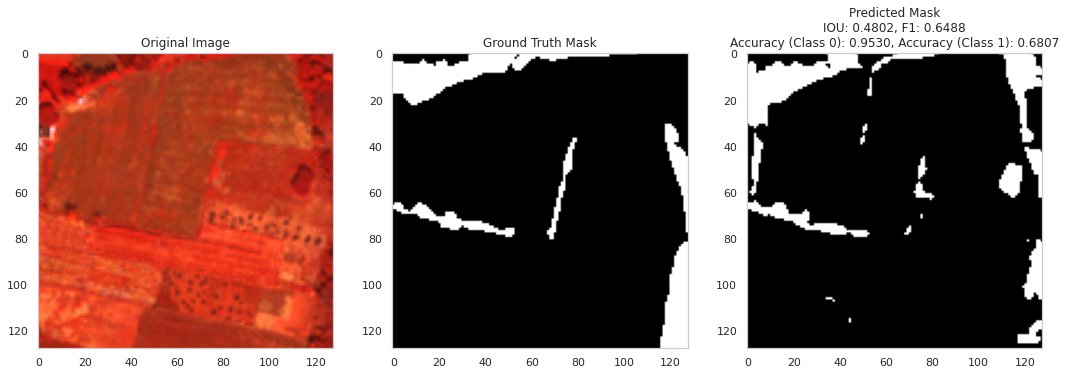

In [94]:
from sklearn.metrics import f1_score, jaccard_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import random

# Function to visualize predictions with metrics
def visualize_test_predictions(images, ground_truth_masks, predicted_masks, num_samples=2):
    for i in range(num_samples):
        idx = random.randint(0, len(images) - 1)
        
        img = images[idx]
        true_mask = ground_truth_masks[idx].flatten()  # Flatten for metric computation
        pred_mask = predicted_masks[idx].flatten()     # Flatten for metric computation
        
        # ✅ Fix: Properly Normalize the Image Before Display
        img = np.array(img, dtype=np.float32)  # Ensure it's float32
        img = img - img.min()  # Shift values to start from 0
        img = img / (img.max() + 1e-7)  # Normalize to [0, 1] (avoid division by zero)
        img_denorm = (img * 255).astype(np.uint8)  # Scale to 8-bit

        # Compute metrics
        iou = jaccard_score(true_mask, pred_mask)
        f1 = f1_score(true_mask, pred_mask)
        
        # Compute confusion matrix to get TP, TN, FP, FN
        tn, fp, fn, tp = confusion_matrix(true_mask, pred_mask, labels=[0, 1]).ravel()
        
        # Compute class-wise accuracy
        accuracy_class_0 = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        accuracy_class_1 = tp / (tp + fn) if (tp + fn) > 0 else 0  # Avoid division by zero
        
        # Plot original image, true mask, and predicted mask
        plt.figure(figsize=(18, 6))
        
        plt.subplot(131)
        plt.imshow(img_denorm.squeeze(), cmap='gray')  # ✅ Fixed dark image issue
        plt.grid(False)
        plt.title('Original Image')

        plt.subplot(132)
        plt.imshow(ground_truth_masks[idx].squeeze(), cmap='gray')
        plt.grid(False)
        plt.title('Ground Truth Mask')

        plt.subplot(133)
        plt.imshow(predicted_masks[idx].squeeze(), cmap='gray')
        plt.grid(False)
        plt.title(f'Predicted Mask\nIOU: {iou:.4f}, F1: {f1:.4f}\n'
                  f'Accuracy (Class 0): {accuracy_class_0:.4f}, Accuracy (Class 1): {accuracy_class_1:.4f}')
        
        plt.show()

# Call the function to visualize predictions with metrics
visualize_test_predictions(X_test, y_test, y_pred_thresholded)

In [95]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
from matplotlib.colors import ListedColormap

def export_test_predictions(images, ground_truth_masks, predicted_masks,
                            output_dir="/home/pc4dl/satya/Model_development/Output10082026",
                            prefix="chip"):
    os.makedirs(output_dir, exist_ok=True)

    num_samples = images.shape[0]

    # Custom binary colormap: [Background, FMV]
    binary_cmap = ListedColormap(["#0B1A3D", "#9EAD3D"])

    for i in range(num_samples):
        img = images[i]
        true_mask = ground_truth_masks[i].squeeze()
        pred_mask = predicted_masks[i].squeeze()

        # Normalize image
        img = np.array(img, dtype=np.float32)
        img = img - img.min()
        img = img / (img.max() + 1e-7)
        img_denorm = (img * 255).astype(np.uint8)

        # Compute F1 score
        true_flat = true_mask.flatten()
        pred_flat = pred_mask.flatten()
        f1 = f1_score(true_flat, pred_flat, average='binary')

        # Plot and save
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))

        axs[0].imshow(img_denorm.squeeze(), cmap='gray')
        axs[0].set_title('Original Image')
        axs[0].axis('off')

        axs[1].imshow(true_mask, cmap=binary_cmap, vmin=0, vmax=1)
        axs[1].set_title('Ground Truth Mask')
        axs[1].axis('off')

        axs[2].imshow(pred_mask, cmap=binary_cmap, vmin=0, vmax=1)
        axs[2].set_title(f'Predicted Mask\nF1: {f1:.4f}')
        axs[2].axis('off')

        # ✅ Save with unique filename (chip_000.png, chip_001.png, ...)
        filename = f"{prefix}_{i:03d}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, bbox_inches='tight')
        plt.close(fig)

    print(f"\n✅ Exported {num_samples} prediction results to: {output_dir}")

In [96]:
export_test_predictions(
    X_test, y_test, y_pred_thresholded,
    output_dir="/home/pc4dl/satya/Model_development/Output10082026",
    prefix="chip"
)

/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1495: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(
/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1495: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(



✅ Exported 144 prediction results to: /home/pc4dl/satya/Model_development/Output10082026



✅ Exported 144 prediction results to: /home/pc4dl/satya/Model_development/Output10082026


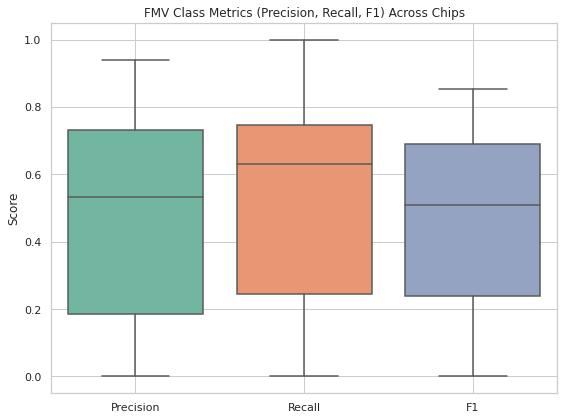

In [97]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

def export_and_plot_fmv_metrics(images, ground_truth_masks, predicted_masks,
                                output_dir="/home/pc4dl/satya/Model_development/Output10082026",
                                export_images=False, prefix="chip"):
    os.makedirs(output_dir, exist_ok=True)

    binary_cmap = ListedColormap(["#0B1A3D", "#3BBD3A"])
    metrics = []  # To store per-chip FMV metrics

    for i in range(images.shape[0]):
        img = images[i]
        true_mask = ground_truth_masks[i].squeeze()
        pred_mask = predicted_masks[i].squeeze()

        true_flat = true_mask.flatten()
        pred_flat = pred_mask.flatten()

        # --- Compute FMV (class 1) metrics only ---
        precision = precision_score(true_flat, pred_flat, pos_label=1, zero_division=0)
        recall = recall_score(true_flat, pred_flat, pos_label=1, zero_division=0)
        f1 = f1_score(true_flat, pred_flat, pos_label=1, zero_division=0)
        metrics.append({'Precision': precision, 'Recall': recall, 'F1': f1})

        # --- Optionally export images ---
        if export_images:
            # Normalize image
            img = np.array(img, dtype=np.float32)
            img = img - img.min()
            img = img / (img.max() + 1e-7)
            img_denorm = (img * 255).astype(np.uint8)

            fig, axs = plt.subplots(1, 3, figsize=(18, 6))
            axs[0].imshow(img_denorm.squeeze(), cmap='gray')
            axs[0].set_title('Original Image')
            axs[0].axis('off')

            axs[1].imshow(true_mask, cmap=binary_cmap, vmin=0, vmax=1)
            axs[1].set_title('Ground Truth Mask')
            axs[1].axis('off')

            axs[2].imshow(pred_mask, cmap=binary_cmap, vmin=0, vmax=1)
            axs[2].set_title(f'Predicted Mask\nPrecision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}')
            axs[2].axis('off')

            filename = f"{prefix}_{i:03d}.png"
            filepath = os.path.join(output_dir, filename)
            plt.savefig(filepath, bbox_inches='tight')
            plt.close(fig)

    print(f"\n✅ Exported {len(metrics)} prediction results to: {output_dir}")

    # --- Convert to DataFrame and Plot Box Plot ---
    df_metrics = pd.DataFrame(metrics)

    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_metrics, palette="Set2")
    plt.title("FMV Class Metrics (Precision, Recall, F1) Across Chips")
    plt.ylabel("Score")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df_metrics
fmv_metrics_df = export_and_plot_fmv_metrics(X_test, y_test, y_pred_thresholded)

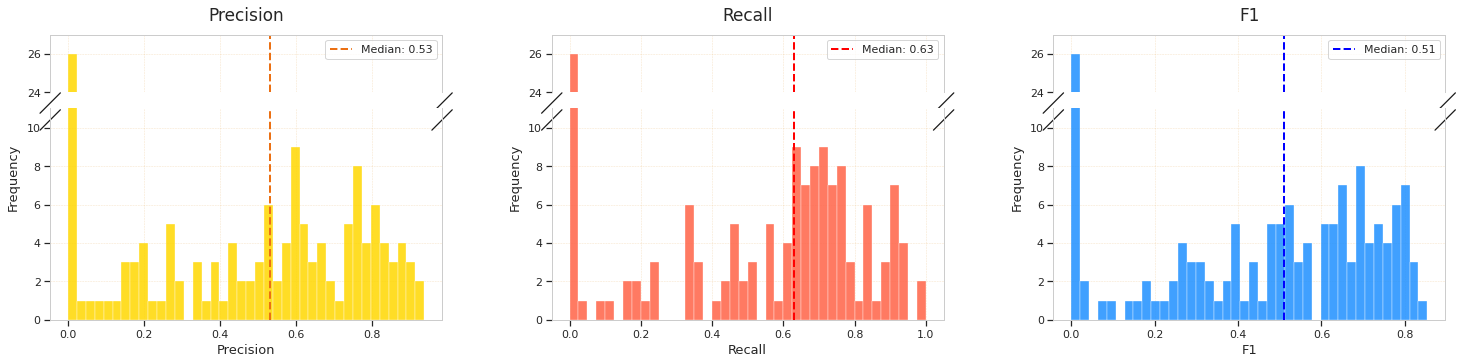

✅ Histogram saved to: fmv_Rural_histogram.png


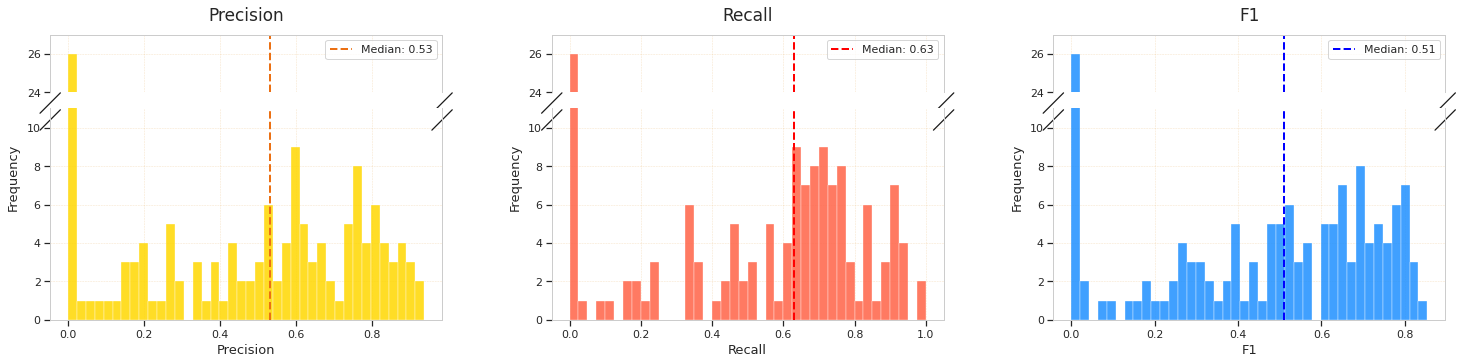

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import gridspec
from brokenaxes import brokenaxes

def plot_clean_fmv_histograms_with_ybreak(fmv_metrics_df, save_path=None):
    metrics = ['Precision', 'Recall', 'F1']
    colors = ['gold', 'tomato', 'dodgerblue']
    line_colors = ['#EB7013', 'red', 'blue']

    sns.set(style="whitegrid", context="notebook")

    fig = plt.figure(figsize=(25, 5.5))
    sns.set(style="whitegrid", context="notebook")
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.28)

    # Better y-axis break
    ylims = ((0, 11), (24, 27))

    for i, metric in enumerate(metrics):
        data = fmv_metrics_df[metric].dropna()
        median_val = np.median(data)

        bax = brokenaxes(
            ylims=ylims,
            subplot_spec=gs[i],
            fig=fig,
            hspace=0.12,   # more space between broken axes
            d=0.008,
            despine=False
        )

        bax.hist(
            data,
            bins=40,
            color=colors[i],
            edgecolor='white',
            linewidth=0.4,
            alpha=0.85
        )

        bax.axvline(
            median_val,
            color=line_colors[i],
            linestyle='--',
            linewidth=2,
            label=f"Median: {median_val:.2f}"
        )

        bax.set_title(metric, fontsize=17, pad=14)
        bax.set_xlabel(metric, fontsize=13, labelpad=24)
        bax.set_ylabel("Frequency", fontsize=13, labelpad=30)

        bax.legend(fontsize=11, loc='upper right', frameon=True)

        bax.grid(
            True,
            linestyle='--',
            linewidth=0.5,
            color='#E8AE5F',
            alpha=0.35
        )

        # Improve tick size and spine appearance
        for ax in bax.axs:
            ax.tick_params(axis='both', labelsize=11)
            for spine in ax.spines.values():
                spine.set_linewidth(1)
                #spine.set_edgecolor('black')
          
    plt.subplots_adjust(bottom=0.18, top=0.90)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Histogram saved to: {save_path}")
    else:
        plt.show()


plot_clean_fmv_histograms_with_ybreak(fmv_metrics_df)
plot_clean_fmv_histograms_with_ybreak(
    fmv_metrics_df,
    save_path="fmv_Rural_histogram.png"
)

## Tranasition test Experiment

In [98]:
#Another test dataset from transition zone
test_image_dir = os.path.join(base_dir, 'TestingT', 'Image')
test_mask_dir = os.path.join(base_dir, 'TestingT', 'labels')

In [99]:
# Load test images and masks 
print("Loading test data...")
X_test, y_test = load_images_and_masks(test_image_dir, test_mask_dir)

Loading test data...


In [100]:
# Preprocess test images
preprocess_input = sm.get_preprocessing('resnet34')
X_test = preprocess_input(X_test)
# Predict on test data
y_pred = model.predict(X_test)

# Apply a threshold to convert probabilities to binary masks
y_pred_thresholded = (y_pred > 0.5).astype('float32')

5/5 [==============================] - 0s 28ms/step


In [101]:
from sklearn.metrics import precision_score, recall_score, average_precision_score
import numpy as np

# Evaluate model on test data (Loss, Binary Accuracy, IOU, F1 Score)
loss, binary_accuracy, iou_score, f1_score = model.evaluate(X_test, y_test, verbose=1)

# Make predictions on test data
y_test_pred = model.predict(X_test, batch_size=batch_size, verbose=1)

# Convert probabilities to binary masks (threshold = 0.5)
y_test_pred_binary = (y_test_pred > 0.7).astype(np.uint8)

# Flatten arrays for metric calculation
y_test_flat = y_test.flatten()
y_test_pred_flat = y_test_pred_binary.flatten()

# Calculate Precision, Recall, and PR-AUC
test_precision = precision_score(y_test_flat, y_test_pred_flat)
test_recall = recall_score(y_test_flat, y_test_pred_flat)
test_pr_auc = average_precision_score(y_test_flat, y_test_pred_flat)

# Print all test metrics
print("\n=== Test Evaluation Metrics ===")
print("Test Loss:", loss)
print("Test Binary Accuracy:", binary_accuracy)
print("Test IOU Score:", iou_score)
print("Test F1 Score:", f1_score)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test PR-AUC:", test_pr_auc)

18/18 [==============================] - 0s 11ms/step

=== Test Evaluation Metrics ===
Test Loss: 0.6653269529342651
Test Binary Accuracy: 0.9650272727012634
Test IOU Score: 0.2891799807548523
Test F1 Score: 0.4476674199104309
Test Precision: 0.533942193295542
Test Recall: 0.3658355310477104
Test PR-AUC: 0.2177578163603976


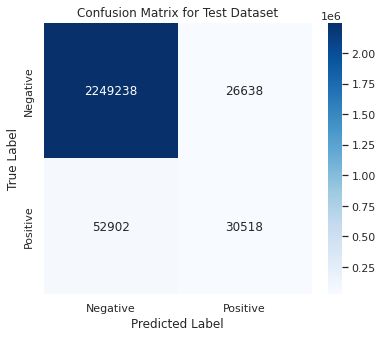

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test_flat, y_test_pred_flat)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Test Dataset")
plt.show()

/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1248: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1495: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(


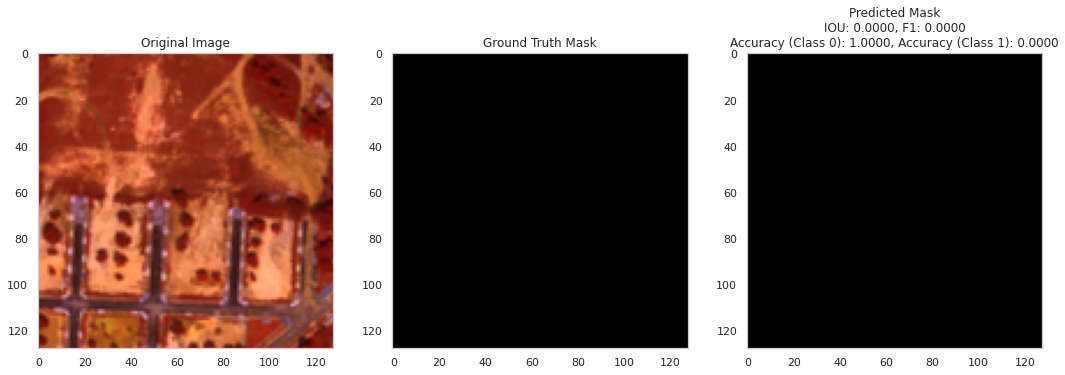

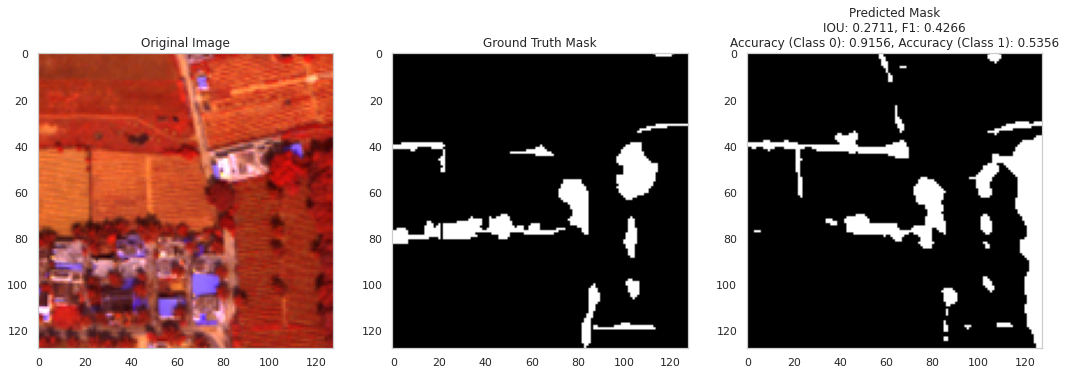

In [103]:
from sklearn.metrics import f1_score, jaccard_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import random

# Function to visualize predictions with metrics
def visualize_test_predictions(images, ground_truth_masks, predicted_masks, num_samples=2):
    for i in range(num_samples):
        idx = random.randint(0, len(images) - 1)
        
        img = images[idx]
        true_mask = ground_truth_masks[idx].flatten()  # Flatten for metric computation
        pred_mask = predicted_masks[idx].flatten()     # Flatten for metric computation
        
        # ✅ Fix: Properly Normalize the Image Before Display
        img = np.array(img, dtype=np.float32)  # Ensure it's float32
        img = img - img.min()  # Shift values to start from 0
        img = img / (img.max() + 1e-7)  # Normalize to [0, 1] (avoid division by zero)
        img_denorm = (img * 255).astype(np.uint8)  # Scale to 8-bit

        # Compute metrics
        iou = jaccard_score(true_mask, pred_mask)
        f1 = f1_score(true_mask, pred_mask)
        
        # Compute confusion matrix to get TP, TN, FP, FN
        tn, fp, fn, tp = confusion_matrix(true_mask, pred_mask, labels=[0, 1]).ravel()
        
        # Compute class-wise accuracy
        accuracy_class_0 = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        accuracy_class_1 = tp / (tp + fn) if (tp + fn) > 0 else 0  # Avoid division by zero
        
        # Plot original image, true mask, and predicted mask
        plt.figure(figsize=(18, 6))
        
        plt.subplot(131)
        plt.imshow(img_denorm.squeeze(), cmap='gray')  # ✅ Fixed dark image issue
        plt.grid(False)
        plt.title('Original Image')

        plt.subplot(132)
        plt.imshow(ground_truth_masks[idx].squeeze(), cmap='gray')
        plt.grid(False)
        plt.title('Ground Truth Mask')

        plt.subplot(133)
        plt.imshow(predicted_masks[idx].squeeze(), cmap='gray')
        plt.grid(False)
        plt.title(f'Predicted Mask\nIOU: {iou:.4f}, F1: {f1:.4f}\n'
                  f'Accuracy (Class 0): {accuracy_class_0:.4f}, Accuracy (Class 1): {accuracy_class_1:.4f}')
        
        plt.show()

# Call the function to visualize predictions with metrics
visualize_test_predictions(X_test, y_test, y_pred_thresholded)


✅ Exported 144 prediction results to: /home/pc4dl/satya/Model_development/Output10082026_T


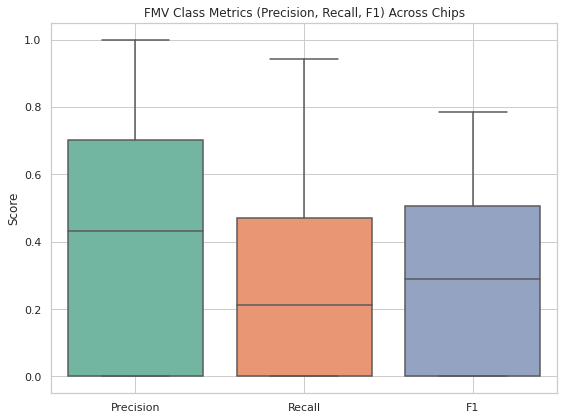

In [104]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

def export_and_plot_fmv_metrics(images, ground_truth_masks, predicted_masks,
                                output_dir="/home/pc4dl/satya/Model_development/Output10082026_T",
                                export_images=False, prefix="chip"):
    os.makedirs(output_dir, exist_ok=True)

    binary_cmap = ListedColormap(["#0B1A3D", "#3BBD3A"])
    metrics = []  # To store per-chip FMV metrics

    for i in range(images.shape[0]):
        img = images[i]
        true_mask = ground_truth_masks[i].squeeze()
        pred_mask = predicted_masks[i].squeeze()

        true_flat = true_mask.flatten()
        pred_flat = pred_mask.flatten()

        # --- Compute FMV (class 1) metrics only ---
        precision = precision_score(true_flat, pred_flat, pos_label=1, zero_division=0)
        recall = recall_score(true_flat, pred_flat, pos_label=1, zero_division=0)
        f1 = f1_score(true_flat, pred_flat, pos_label=1, zero_division=0)
        metrics.append({'Precision': precision, 'Recall': recall, 'F1': f1})

        # --- Optionally export images ---
        if export_images:
            # Normalize image
            img = np.array(img, dtype=np.float32)
            img = img - img.min()
            img = img / (img.max() + 1e-7)
            img_denorm = (img * 255).astype(np.uint8)

            fig, axs = plt.subplots(1, 3, figsize=(18, 6))
            axs[0].imshow(img_denorm.squeeze(), cmap='gray')
            axs[0].set_title('Original Image')
            axs[0].axis('off')

            axs[1].imshow(true_mask, cmap=binary_cmap, vmin=0, vmax=1)
            axs[1].set_title('Ground Truth Mask')
            axs[1].axis('off')

            axs[2].imshow(pred_mask, cmap=binary_cmap, vmin=0, vmax=1)
            axs[2].set_title(f'Predicted Mask\nPrecision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}')
            axs[2].axis('off')

            filename = f"{prefix}_{i:03d}.png"
            filepath = os.path.join(output_dir, filename)
            plt.savefig(filepath, bbox_inches='tight')
            plt.close(fig)

    print(f"\n✅ Exported {len(metrics)} prediction results to: {output_dir}")

    # --- Convert to DataFrame and Plot Box Plot ---
    df_metrics = pd.DataFrame(metrics)

    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_metrics, palette="Set2")
    plt.title("FMV Class Metrics (Precision, Recall, F1) Across Chips")
    plt.ylabel("Score")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df_metrics
fmv_metrics_df = export_and_plot_fmv_metrics(X_test, y_test, y_pred_thresholded)

In [105]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
from matplotlib.colors import ListedColormap

def export_test_predictions(images, ground_truth_masks, predicted_masks,
                            output_dir="/home/pc4dl/satya/Model_development/Output10082026_T",
                            prefix="chip"):
    os.makedirs(output_dir, exist_ok=True)

    num_samples = images.shape[0]

    # Custom binary colormap: [Background, FMV]
    binary_cmap = ListedColormap(["#0B1A3D", "#9EAD3D"])

    for i in range(num_samples):
        img = images[i]
        true_mask = ground_truth_masks[i].squeeze()
        pred_mask = predicted_masks[i].squeeze()

        # Normalize image
        img = np.array(img, dtype=np.float32)
        img = img - img.min()
        img = img / (img.max() + 1e-7)
        img_denorm = (img * 255).astype(np.uint8)

        # Compute F1 score
        true_flat = true_mask.flatten()
        pred_flat = pred_mask.flatten()
        f1 = f1_score(true_flat, pred_flat, average='binary')

        # Plot and save
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))

        axs[0].imshow(img_denorm.squeeze(), cmap='gray')
        axs[0].set_title('Original Image')
        axs[0].axis('off')

        axs[1].imshow(true_mask, cmap=binary_cmap, vmin=0, vmax=1)
        axs[1].set_title('Ground Truth Mask')
        axs[1].axis('off')

        axs[2].imshow(pred_mask, cmap=binary_cmap, vmin=0, vmax=1)
        axs[2].set_title(f'Predicted Mask\nF1: {f1:.4f}')
        axs[2].axis('off')

        # ✅ Save with unique filename (chip_000.png, chip_001.png, ...)
        filename = f"{prefix}_{i:03d}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, bbox_inches='tight')
        plt.close(fig)

    print(f"\n✅ Exported {num_samples} prediction results to: {output_dir}")

In [106]:
export_test_predictions(
    X_test, y_test, y_pred_thresholded,
    output_dir="/home/pc4dl/satya/Model_development/Output10082026_T",
    prefix="chip"
)

/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1495: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(
/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1495: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(
/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1495: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(
/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1495: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. U


✅ Exported 144 prediction results to: /home/pc4dl/satya/Model_development/Output10082026_T


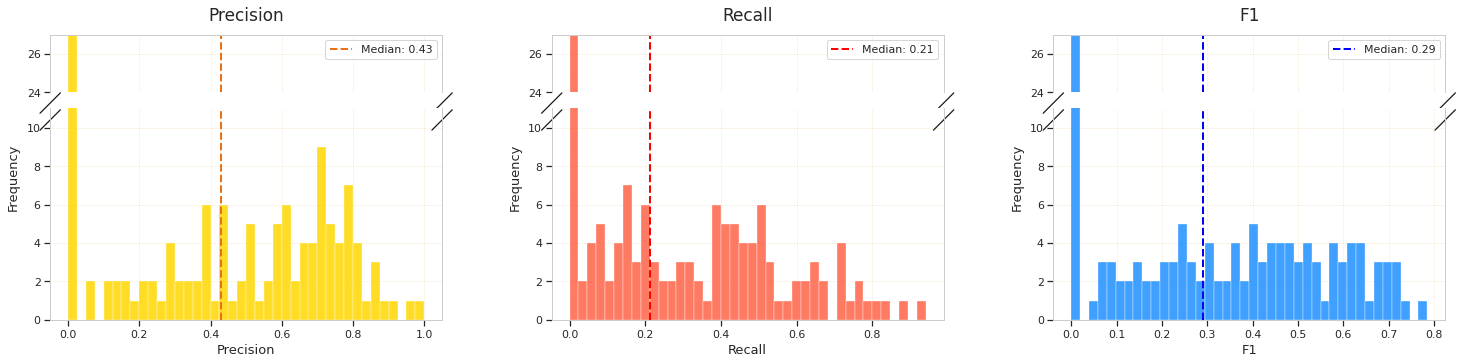

✅ Histogram saved to: fmv_transition_histogram.png


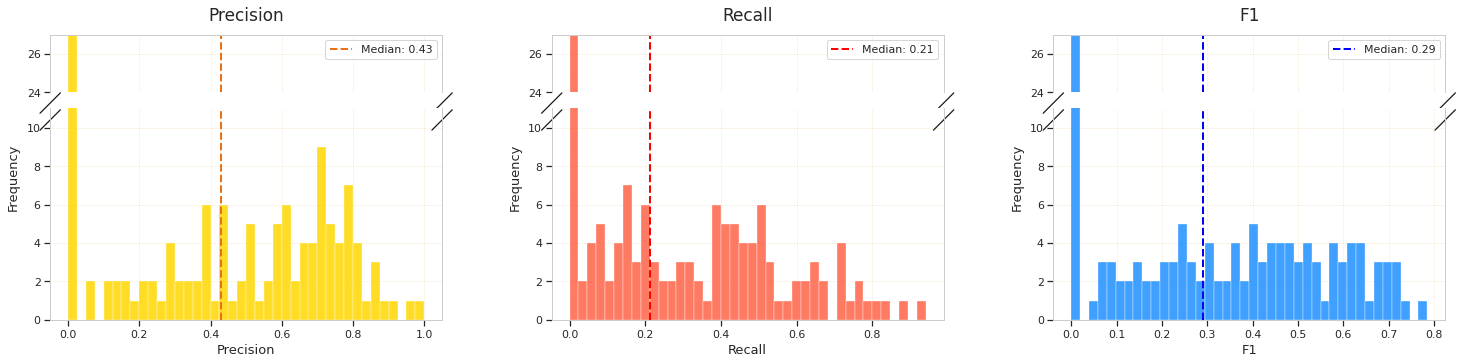

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import gridspec
from brokenaxes import brokenaxes

def plot_clean_fmv_histograms_with_ybreak(fmv_metrics_df, save_path=None):
    metrics = ['Precision', 'Recall', 'F1']
    colors = ['gold', 'tomato', 'dodgerblue']
    line_colors = ['#EB7013', 'red', 'blue']

    sns.set(style="whitegrid", context="notebook")

    fig = plt.figure(figsize=(25, 5.5))
    sns.set(style="whitegrid", context="notebook")
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.28)

    # Better y-axis break
    ylims = ((0, 11), (24, 27))

    for i, metric in enumerate(metrics):
        data = fmv_metrics_df[metric].dropna()
        median_val = np.median(data)

        bax = brokenaxes(
            ylims=ylims,
            subplot_spec=gs[i],
            fig=fig,
            hspace=0.12,   # more space between broken axes
            d=0.008,
            despine=False
        )

        bax.hist(
            data,
            bins=40,
            color=colors[i],
            edgecolor='white',
            linewidth=0.4,
            alpha=0.85
        )

        bax.axvline(
            median_val,
            color=line_colors[i],
            linestyle='--',
            linewidth=2,
            label=f"Median: {median_val:.2f}"
        )

        bax.set_title(metric, fontsize=17, pad=14)
        bax.set_xlabel(metric, fontsize=13, labelpad=24)
        bax.set_ylabel("Frequency", fontsize=13, labelpad=30)

        bax.legend(fontsize=11, loc='upper right', frameon=True)

        bax.grid(
            True,
            linestyle='--',
            linewidth=0.5,
            color='#E8AE5F',
            alpha=0.35
        )

        # Improve tick size and spine appearance
        for ax in bax.axs:
            ax.tick_params(axis='both', labelsize=11)
            for spine in ax.spines.values():
                spine.set_linewidth(1)
                #spine.set_edgecolor('black')
          
    plt.subplots_adjust(bottom=0.18, top=0.90)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Histogram saved to: {save_path}")
    else:
        plt.show()


plot_clean_fmv_histograms_with_ybreak(fmv_metrics_df)
plot_clean_fmv_histograms_with_ybreak(
    fmv_metrics_df,
    save_path="fmv_transition_histogram.png"
)

## Predict FMV for whole study area

In [107]:
import os
from glob import glob
from pathlib import Path
import numpy as np
import rasterio
from rasterio.merge import merge

# CONFIG
base_dir = "/home/pc4dl/satya/Model_development"
test_image_dir = os.path.join(base_dir, "Forwholetransect", "Image")
pred_dir       = os.path.join(base_dir, "Forwholetransect", "Prediction3")
os.makedirs(pred_dir, exist_ok=True)

# Model preprocessing
preprocess_input = sm.get_preprocessing('resnet34')

# MAIN LOOP
chip_paths = sorted(glob(os.path.join(test_image_dir, "*.tif")))
print(f"Found {len(chip_paths)} test chips")

predicted_files = []   # <-- keep track of output paths
saved = 0

for chip_path in chip_paths:
    # 1) Load one chip
    with rasterio.open(chip_path) as src:
        img = np.stack([src.read(b) for b in [6, 4, 1]], axis=-1).astype("float32")
        img = np.clip(img, 0, np.percentile(img, 99))  # simple clipping
        H, W, C = img.shape
        profile = src.profile.copy()
        profile.update(
            driver="GTiff",
            count=1,
            dtype=rasterio.uint8,
            compress="lzw",
            nodata=0,
            height=H,
            width=W,
            transform=src.transform,
            crs=src.crs
        )

    # 2) Preprocess + predict
    X = np.expand_dims(img, axis=0)  # (1,H,W,C)
    X = preprocess_input(X)
    y_pred = model.predict(X, verbose=0)

    # 3) Threshold prediction
    if y_pred.ndim == 4 and y_pred.shape[-1] == 1:
        mask = (y_pred[0, :, :, 0] > 0.5).astype(np.uint8)  # binary
    else:
        mask = np.argmax(y_pred[0], axis=-1).astype(np.uint8)  # multi-class

    # 4) Save prediction GeoTIFF
    out_tif = os.path.join(pred_dir, f"{Path(chip_path).stem}_pred.tif")
    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(mask, 1)

    predicted_files.append(out_tif)
    saved += 1
    if saved % 100 == 0:
        print(f"Saved {saved}/{len(chip_paths)}")

print(f"✅ Done! Saved {saved} predicted chip TIFs to {pred_dir}")

Found 44200 test chips
Saved 100/44200
Saved 200/44200
Saved 300/44200
Saved 400/44200
Saved 500/44200
Saved 600/44200
Saved 700/44200
Saved 800/44200
Saved 900/44200
Saved 1000/44200
Saved 1100/44200
Saved 1200/44200
Saved 1300/44200
Saved 1400/44200
Saved 1500/44200
Saved 1600/44200
Saved 1700/44200
Saved 1800/44200
Saved 1900/44200
Saved 2000/44200
Saved 2100/44200
Saved 2200/44200
Saved 2300/44200
Saved 2400/44200
Saved 2500/44200
Saved 2600/44200
Saved 2700/44200
Saved 2800/44200
Saved 2900/44200
Saved 3000/44200
Saved 3100/44200
Saved 3200/44200
Saved 3300/44200
Saved 3400/44200
Saved 3500/44200
Saved 3600/44200
Saved 3700/44200
Saved 3800/44200
Saved 3900/44200
Saved 4000/44200
Saved 4100/44200
Saved 4200/44200
Saved 4300/44200
Saved 4400/44200
Saved 4500/44200
Saved 4600/44200
Saved 4700/44200
Saved 4800/44200
Saved 4900/44200
Saved 5000/44200
Saved 5100/44200
Saved 5200/44200
Saved 5300/44200
Saved 5400/44200
Saved 5500/44200
Saved 5600/44200
Saved 5700/44200
Saved 5800/44200


In [108]:
def _to_2d_single_band(arr, reduce="max"):
    """
    Convert merge() output to a 2D array suitable for writing to band 1.
    - Accepts ndarray or MaskedArray with shapes like:
      (H,W), (1,H,W), (B,H,W), (1,1,H,W)
    - If multi-band (B>1), reduce across band axis using 'max'/'mean'/'first'.
    """
    import numpy as np
    # Fill masked arrays with 0
    if hasattr(arr, "mask"):
        arr = arr.filled(0)

    a = np.asarray(arr)

    # Squeeze all leading singleton dims except the last 2 (H,W)
    while a.ndim > 2 and a.shape[0] == 1:
        a = np.squeeze(a, axis=0)

    if a.ndim == 2:
        return a

    if a.ndim == 3:
        # a is (B,H,W)
        if a.shape[0] == 1:
            return a[0]
        if reduce == "max":
            return a.max(axis=0)
        elif reduce == "mean":
            return a.mean(axis=0)
        elif reduce == "first":
            return a[0]
        else:
            raise ValueError(f"Unknown reduce='{reduce}'")

    raise ValueError(f"Unexpected merged array ndim={a.ndim}, shape={a.shape}")

In [109]:
from contextlib import ExitStack
import rasterio
from rasterio.merge import merge
import numpy as np

def merge_predictions_batched(predicted_files, merged_out, method="max", batch_size=3000):
    import os, uuid, tempfile

    os.makedirs(os.path.dirname(merged_out), exist_ok=True)
    tmpdir = tempfile.mkdtemp(prefix="mosaic_batches_")
    temp_mosaics = []

    # 1) batch merge to temporary mosaics
    total = len(predicted_files)
    for i in range(0, total, batch_size):
        batch = predicted_files[i:i+batch_size]
        print(f"Batch {i//batch_size+1}/{(total+batch_size-1)//batch_size}: {len(batch)} tiles")
        with ExitStack() as stack:
            srcs = [stack.enter_context(rasterio.open(p)) for p in batch]
            merged, out_transform = merge(srcs, method=method)

            data2d = _to_2d_single_band(merged, reduce="max").astype(np.uint8)

            profile = srcs[0].profile
            profile.update(
                height=data2d.shape[0],
                width=data2d.shape[1],
                transform=out_transform,
                count=1,
                dtype=rasterio.uint8,
                compress="lzw",
                nodata=0
            )

        tmp_path = os.path.join(tmpdir, f"batch_{i//batch_size+1:04d}_{uuid.uuid4().hex}.tif")
        with rasterio.open(tmp_path, "w", **profile) as dst:
            dst.write(data2d, 1)
        temp_mosaics.append(tmp_path)

    # 2) final merge of temporary mosaics
    print(f"Merging {len(temp_mosaics)} temporary mosaics into final...")
    with ExitStack() as stack:
        srcs = [stack.enter_context(rasterio.open(p)) for p in temp_mosaics]
        merged, out_transform = merge(srcs, method=method)
        data2d = _to_2d_single_band(merged, reduce="max").astype(np.uint8)

        profile = srcs[0].profile
        profile.update(
            height=data2d.shape[0],
            width=data2d.shape[1],
            transform=out_transform,
            count=1,
            dtype=rasterio.uint8,
            compress="lzw",
            nodata=0
        )

    with rasterio.open(merged_out, "w", **profile) as dst:
        dst.write(data2d, 1)

    # 3) cleanup temps (optional)
    for p in temp_mosaics:
        try: os.remove(p)
        except OSError: pass
    try: os.rmdir(tmpdir)
    except OSError: pass

    print(f"✅ Final mosaic saved: {merged_out}")
    return merged_out

# usage
merge_out = os.path.join(pred_dir, "prediction_merge.tif")
merge_predictions_batched(predicted_files, merge_out, method="max", batch_size=3000)

Batch 1/15: 3000 tiles
Batch 2/15: 3000 tiles
Batch 3/15: 3000 tiles
Batch 4/15: 3000 tiles
Batch 5/15: 3000 tiles
Batch 6/15: 3000 tiles
Batch 7/15: 3000 tiles
Batch 8/15: 3000 tiles
Batch 9/15: 3000 tiles
Batch 10/15: 3000 tiles
Batch 11/15: 3000 tiles
Batch 12/15: 3000 tiles
Batch 13/15: 3000 tiles
Batch 14/15: 3000 tiles
Batch 15/15: 2200 tiles
Merging 15 temporary mosaics into final...
✅ Final mosaic saved: /home/pc4dl/satya/Model_development/Forwholetransect/Prediction3/prediction_merge.tif


'/home/pc4dl/satya/Model_development/Forwholetransect/Prediction3/prediction_merge.tif'

✅ Opened prediction_merge.tif | shape=41664x4416 | downsample x20 | dtype=uint8 | nodata=0.0
   min=0, max=1, unique(sample)=[0 1]


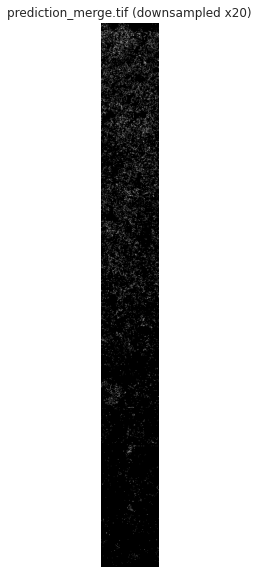

In [110]:
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from rasterio.enums import Resampling

def preview_raster(path, max_size=2000, cmap="gray", mask_nodata=True):
    if not os.path.exists(path):
        print(f" File not found: {path}")
        return

    with rasterio.open(path) as src:
        H, W = src.height, src.width
        nodata = src.nodata
        scale = max(1, int(max(W, H) / max_size))
        # Explicit resampling for clarity
        data = src.read(
            1,
            out_shape=(H // scale, W // scale),
            resampling=Resampling.nearest
        )

    print(f"✅ Opened {Path(path).name} | shape={H}x{W} | downsample x{scale} | dtype={data.dtype} | nodata={nodata}")
    print(f"   min={data.min()}, max={data.max()}, unique(sample)={np.unique(data)[:10]}")

    # Only mask if nodata is set and not 0 (to keep binary 0 background visible)
    if mask_nodata and nodata is not None and nodata != 0:
        data = np.ma.masked_equal(data, nodata)

    plt.figure(figsize=(10,10))
    # Help contrast for binary masks
    if cmap == "gray":
        plt.imshow(data, cmap=cmap, vmin=0, vmax=max(1, int(data.max())))
    else:
        plt.imshow(data, cmap=cmap)
    plt.title(f"{Path(path).name} (downsampled x{scale})")
    plt.axis("off")
    plt.show()
# For binary mask mosaic (don’t mask zeros):
preview_raster(merge_out, cmap="gray", mask_nodata=False)

In [111]:
import rasterio
import numpy as np

def calculate_class_areas(raster_path, background_class=0, fmv_class=1):
    with rasterio.open(raster_path) as src:
        data = src.read(1)              # single-band mask
        transform = src.transform
        nodata = src.nodata

        # Pixel size (assuming square pixels)
        pixel_width = abs(transform.a)
        pixel_height = abs(transform.e)
        pixel_area = pixel_width * pixel_height  # in map units² (e.g., m² if CRS is UTM)

        # Mask out nodata if defined
        if nodata is not None:
            data = np.ma.masked_equal(data, nodata)

        # Count pixels for each class
        background_pixels = np.sum(data == background_class)
        fmv_pixels = np.sum(data == fmv_class)

        # Convert to area
        background_area = background_pixels * pixel_area
        fmv_area = fmv_pixels * pixel_area

    return {
        "background_pixels": int(background_pixels),
        "fmv_pixels": int(fmv_pixels),
        "pixel_area": pixel_area,
        "background_area": background_area,
        "fmv_area": fmv_area
    }

# Example usage:
results = calculate_class_areas(merge_out)
print("Pixel size (area per pixel):", results["pixel_area"])
print("Background pixels:", results["background_pixels"], 
      "→ area:", results["background_area"])
print("FMV pixels:", results["fmv_pixels"], 
      "→ area:", results["fmv_area"])

Pixel size (area per pixel): 1.44
Background pixels: 0 → area: 0.0
FMV pixels: 8049033 → area: 11590607.52


In [112]:
import math
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np

def _guess_utm_crs_from_bounds(src):
    """Pick a UTM EPSG based on the raster centroid (lon/lat)."""
    from rasterio.warp import transform_bounds
    # Get bounds in WGS84
    left, bottom, right, top = transform_bounds(src.crs, "EPSG:4326", *src.bounds, densify_pts=21)
    lon = (left + right) / 2.0
    lat = (bottom + top) / 2.0
    zone = int(math.floor((lon + 180) / 6) + 1)
    hemi = 326 if lat >= 0 else 327  # 326xx = north, 327xx = south
    return f"EPSG:{hemi:03d}{zone:02d}"

def reproject_to_projected(src_path, dst_path=None, dst_crs=None):
    """
    Reproject a single-band categorical raster to a projected CRS (meters).
    Uses nearest-neighbor to preserve class labels.
    Returns the path to the reprojected file (or None if not written) and an open dataset object.
    """
    src = rasterio.open(src_path)

    # If already projected in meters, we can just return the open dataset
    if dst_crs is None:
        # If geographic (lat/lon), choose UTM; else keep current CRS
        if src.crs and src.crs.is_geographic:
            dst_crs = _guess_utm_crs_from_bounds(src)
        else:
            return None, src  # no reprojection needed

    # Prepare destination transform/shape/profile
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    profile = src.profile.copy()
    profile.update(
        crs=dst_crs,
        transform=transform,
        width=width,
        height=height,
        dtype=rasterio.uint8,   # categorical mask
        count=1,
        compress="lzw",
        nodata=0
    )

    if dst_path is None:
        # Write to a sibling file with suffix _utm.tif
        dst_path = src_path.replace(".tif", "_utm.tif")

    # Do the reprojection (nearest to keep labels intact)
    with rasterio.open(dst_path, "w", **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest,
            dst_nodata=0,
        )

    src.close()
    return dst_path, rasterio.open(dst_path)

def compute_areas(dataset_path, fmv_class=1, background_class=0, ensure_projected=True):
    """
    Compute areas (m² and km²) for background and FMV classes from a single-band raster.
    If ensure_projected is True and the CRS is geographic (degrees), the raster
    is reprojected to UTM before measuring areas.
    """
    if ensure_projected:
        # Reproject to UTM if needed
        reproj_path, ds = reproject_to_projected(dataset_path)
        if ds is None:
            # Already projected; open original
            ds = rasterio.open(dataset_path)
            reproj_path = dataset_path
    else:
        ds = rasterio.open(dataset_path)
        reproj_path = dataset_path

    with ds:
        arr = ds.read(1)
        nodata = ds.nodata
        # Pixel size in meters (projected CRS)
        pixel_w, pixel_h = ds.res
        pixel_area_m2 = abs(pixel_w * pixel_h)

        if nodata is not None:
            arr = np.ma.masked_equal(arr, nodata)

        n_bg  = int((arr == background_class).sum())
        n_fmv = int((arr == fmv_class).sum())

        area_bg_m2  = n_bg  * pixel_area_m2
        area_fmv_m2 = n_fmv * pixel_area_m2

    return {
        "raster_used": reproj_path,
        "pixel_size_m": (abs(pixel_w), abs(pixel_h)),
        "pixel_area_m2": pixel_area_m2,
        "background_pixels": n_bg,
        "fmv_pixels": n_fmv,
        "background_area_m2": area_bg_m2,
        "fmv_area_m2": area_fmv_m2,
        "background_area_km2": area_bg_m2 / 1e6,
        "fmv_area_km2": area_fmv_m2 / 1e6,
    }

In [113]:
# Your merged mosaic path
# merge_out = os.path.join(pred_dir, "prediction_merge.tif")

results = compute_areas(merge_out, fmv_class=1, background_class=0, ensure_projected=True)

print("Raster used:", results["raster_used"])
print("Pixel size (m):", results["pixel_size_m"])
print("Pixel area (m²):", results["pixel_area_m2"])
print("Background:  pixels =", results["background_pixels"], " area =", results["background_area_m2"], "m² (", results["background_area_km2"], "km² )")
print("FMV:         pixels =", results["fmv_pixels"],       " area =", results["fmv_area_m2"],       "m² (", results["fmv_area_km2"], "km² )")

Raster used: None
Pixel size (m): (1.2, 1.2)
Pixel area (m²): 1.44
Background:  pixels = 0  area = 0.0 m² ( 0.0 km² )
FMV:         pixels = 8049033  area = 11590607.52 m² ( 11.590607519999999 km² )
